# STE vs Top-2 with DTSemNet Classification


Summary:
1. create a dtsemnet-topk teacher network
2. create dataset using that network
3. copy the network to a student network
    - freeze all weights except root node

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



# Fix seed for reproducibility
seed = 100
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)


/home/subratpp/miniconda3/envs/dprl/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Create Teacher Network

model input dim = 2

num of classes = 1 # for regression

depth = 5

In [2]:
from dprl.agents.dtsemnet_topk import DTSemNet

teacher_model = DTSemNet(
                in_dim=2,
                out_dim=1,
                height=5,
                is_regression=True,
                over_param=[],
                linear_control=True,
                wt_init='none',
                reg_hidden=0,
                ste = "hard_argmax_ste",
                top_k=2,
                detach=False,
                smax_temp= 0.5,
                batch_norm=False,
            )

In [3]:
target_w = teacher_model.linear1[0].weight.data[0]
W1 = target_w[0].item()
W2 = target_w[1].item()
print('Target Weight', W1, W2)

Target Weight -0.5491896271705627 0.4466696083545685


## 2. Create Custom Dataset from Teacher




In [4]:
# Generate dataset
def generate_data(model, n_samples=1000, low=-1.0, high=1.0):
    # Generate uniformly distributed random samples between low and high
    x = torch.rand(n_samples, 2) * (high - low) + low  # Uniformly sample between low and high
    
    with torch.no_grad():
        y, _ = model(x, mode='test')

    return x, y

In [5]:
x, y = generate_data(teacher_model, n_samples=30000)
# split
train_size = int(0.8 * len(x))
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

In [6]:
len(x_train), len(y_train), len(x_test), len(y_test)

(24000, 24000, 6000, 6000)

In [7]:
# 🔹 Generate 3D mesh for loss landscape
def generate_loss_landscape(model, x_train, y_train, w1_range, w2_range):
    loss_fn = nn.MSELoss()
    w1, w2 = np.meshgrid(w1_range, w2_range)
    z = np.zeros_like(w1)
    
    for i in range(w1.shape[0]):
        for j in range(w1.shape[1]):
            model.linear1[0].weight.data[0][0] = torch.tensor(w1[i, j])
            model.linear1[0].weight.data[0][1] = torch.tensor(w2[i, j])
            output, _ = model(x_train, mode='test')
            loss = loss_fn(output, y_train)
            z[i, j] = loss.item()
            # print(z[i,j])
    
    return w1, w2, z

# Plot 3D loss landscape with weight trajectories
def plot_3d_landscape_with_trajectories(loss_landscape):
    w1, w2, z = loss_landscape
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot loss landscape
    surf = ax.plot_surface(w1, w2, z, cmap='viridis', alpha=0.6)
    
    
    # ax.scatter(0.8, 0.8, losses[0], color=color, marker='o')
    ax.scatter(W1, W2, 0, color='r', marker='x')
    
    ax.set_xlabel("Weight Dimension 1")
    ax.set_ylabel("Weight Dimension 2")
    ax.set_zlabel("Loss")
    ax.set_title("3D Weight Evolution in Loss Landscape")
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.legend()
    plt.show()




No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


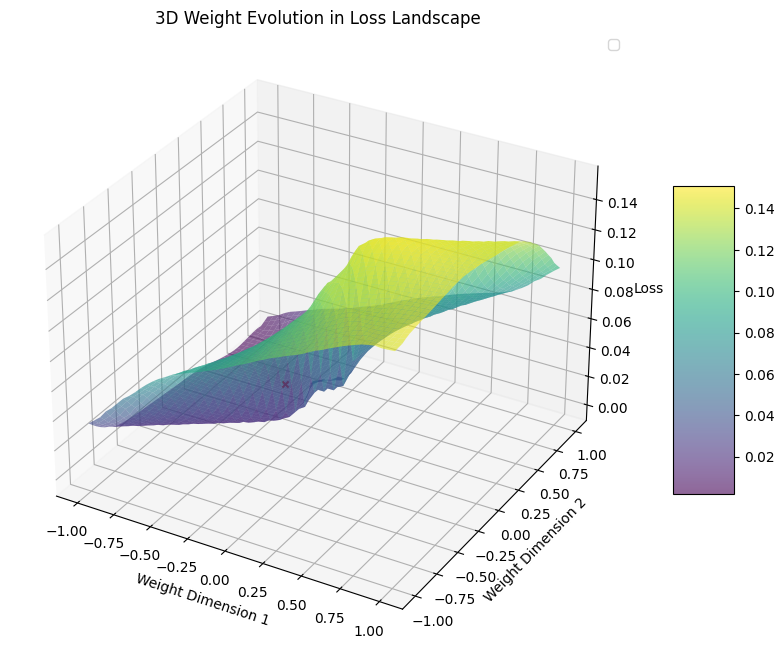

In [8]:
# Generate loss landscape
w1_range = np.linspace(-1, 1, 50)
w2_range = np.linspace(-1, 1, 50)
loss_landscape = generate_loss_landscape(teacher_model, x_train, y_train, w1_range, w2_range)

# Plot combined 3D landscape with trajectories
plot_3d_landscape_with_trajectories(loss_landscape)

## 3. Create Student Network

In [9]:
# initial_wt = [-0.25, 0.25] # student initial weights
initial_wt = [0.25, 0.25]

### Topk Model

In [10]:
# 1. Copy teacher model to student model
student_model_topk = DTSemNet(
    in_dim=2,
    out_dim=1,
    height=5,
    is_regression=True,
    over_param=[],
    linear_control=True,
    wt_init='none',
    reg_hidden=0,
    ste="hard_argmax_ste",
    top_k=2,
    detach=False,
    smax_temp=0.5,
    batch_norm=False, 
)
student_model_topk.load_state_dict(teacher_model.state_dict())

# 2. Freeze all parameters
for param in student_model_topk.parameters():
    param.requires_grad = False


### STE Model

In [11]:
from dprl.agents.dtsemnet_ste import DTSemNet as DTSemNetSTE

student_model_ste = DTSemNetSTE(
                    in_dim=2,
                    out_dim=1,
                    height=5,
                    is_regression=True,
                    over_param=[],
                    linear_control=True,
                    wt_init=False,
                    reg_hidden=0,
                    ste = "hard_argmax_ste",
                    batch_norm=False,
                )


In [12]:
# Assuming teacher_model.linear1 and student_model_ste.linear1 are both Sequentials with same structure
for i, (teacher_layer, student_layer) in enumerate(zip(teacher_model.linear1, student_model_ste.linear1)):
    if isinstance(teacher_layer, torch.nn.Linear) and isinstance(student_layer, torch.nn.Linear):
        student_layer.weight.data.copy_(teacher_layer.weight.data)
        student_layer.bias.data.copy_(teacher_layer.bias.data)

# Assuming both models are already instantiated and teacher_model is loaded

# Stack weights and biases from teacher's experts
expert_weights = []
expert_biases = []

for expert in teacher_model.experts:
    # Each expert has a Linear layer: Linear(2, 1)
    layer = expert.layer
    expert_weights.append(layer.weight.data.clone())  # shape: [1, 2]
    expert_biases.append(layer.bias.data.clone())     # shape: [1]

# Stack into [32, 2] and [32]
combined_weight = torch.cat(expert_weights, dim=0)  # shape: [32, 2]
combined_bias = torch.stack(expert_biases).squeeze()  # shape: [32]

# Assign to student's regression_layer
student_model_ste.regression_layer.weight.data.copy_(combined_weight)
student_model_ste.regression_layer.bias.data.copy_(combined_bias)


# 2. Freeze all parameters
for param in student_model_ste.parameters():
    param.requires_grad = False

### Sanity Check

In [13]:
output, _ = teacher_model(x_train, mode='test')
topk, args = torch.topk(teacher_model.selected_experts, k=1, dim=1)
print(f"Number of 0s in args: {(args == 3).sum().item()}")

Number of 0s in args: 81


In [14]:
output, _ = student_model_topk(x_train, mode='test')
topk, args = torch.topk(student_model_topk.selected_experts, k=1, dim=1)
print(f"Number of 0s in args: {(args == 3).sum().item()}")

Number of 0s in args: 81


In [15]:
output, _ = student_model_ste(x_train, mode='test')
topk, args = torch.topk(student_model_ste.selected_experts, k=1, dim=1)
print(f"Number of 0s in args: {(args == 3).sum().item()}")

Number of 0s in args: 81


### Student Weight Change

In [16]:
## TOPk
# 3. Extract and re-enable only the first row of the first linear layer weight
with torch.no_grad():
    # Overwrite with your custom initial weights if needed
    student_model_topk.linear1[0].weight[0] = torch.tensor(initial_wt)

# 4. Reassign weight as parameter and enable grad for whole tensor (needed for tracking)
student_model_topk.linear1[0].weight = torch.nn.Parameter(student_model_topk.linear1[0].weight)
student_model_topk.linear1[0].weight.requires_grad = True

# print weights for withich grad is enabled
for name, param in student_model_topk.named_parameters():
    if param.requires_grad:
        print(f"Parameter {name} requires grad: {param.data}")

Parameter linear1.0.weight requires grad: tensor([[ 0.2500,  0.2500],
        [-0.3358, -0.0228],
        [ 0.2496,  0.3591],
        [-0.3356, -0.6465],
        [-0.4129, -0.5402],
        [-0.5350,  0.3332],
        [ 0.2995,  0.4067],
        [-0.1155,  0.5677],
        [ 0.7027,  0.3628],
        [-0.3905, -0.2795],
        [-0.4548,  0.4580],
        [ 0.0788,  0.6746],
        [-0.0792,  0.6333],
        [ 0.3458, -0.0153],
        [-0.3641,  0.2833],
        [ 0.0392, -0.3575],
        [ 0.4114, -0.1082],
        [-0.6832, -0.3947],
        [ 0.6414,  0.2919],
        [-0.4768,  0.5518],
        [ 0.0230, -0.6564],
        [ 0.2088, -0.2220],
        [-0.2570,  0.0369],
        [-0.6439,  0.0175],
        [ 0.5729,  0.1398],
        [-0.0778,  0.3222],
        [-0.0619, -0.2279],
        [ 0.1713,  0.0750],
        [ 0.2681, -0.1856],
        [ 0.5731,  0.4746],
        [-0.2773,  0.2441]])


In [17]:
## STE

# 3. Extract and re-enable only the first row of the first linear layer weight
with torch.no_grad():
    # Overwrite with your custom initial weights if needed
    student_model_ste.linear1[0].weight[0] = torch.tensor(initial_wt)

# 4. Reassign weight as parameter and enable grad for whole tensor (needed for tracking)
student_model_ste.linear1[0].weight = torch.nn.Parameter(student_model_ste.linear1[0].weight)
student_model_ste.linear1[0].weight.requires_grad = True

# print weights for withich grad is enabled
for name, param in student_model_ste.named_parameters():
    if param.requires_grad:
        print(f"Parameter {name} requires grad: {param.data}")

Parameter linear1.0.weight requires grad: tensor([[ 0.2500,  0.2500],
        [-0.3358, -0.0228],
        [ 0.2496,  0.3591],
        [-0.3356, -0.6465],
        [-0.4129, -0.5402],
        [-0.5350,  0.3332],
        [ 0.2995,  0.4067],
        [-0.1155,  0.5677],
        [ 0.7027,  0.3628],
        [-0.3905, -0.2795],
        [-0.4548,  0.4580],
        [ 0.0788,  0.6746],
        [-0.0792,  0.6333],
        [ 0.3458, -0.0153],
        [-0.3641,  0.2833],
        [ 0.0392, -0.3575],
        [ 0.4114, -0.1082],
        [-0.6832, -0.3947],
        [ 0.6414,  0.2919],
        [-0.4768,  0.5518],
        [ 0.0230, -0.6564],
        [ 0.2088, -0.2220],
        [-0.2570,  0.0369],
        [-0.6439,  0.0175],
        [ 0.5729,  0.1398],
        [-0.0778,  0.3222],
        [-0.0619, -0.2279],
        [ 0.1713,  0.0750],
        [ 0.2681, -0.1856],
        [ 0.5731,  0.4746],
        [-0.2773,  0.2441]])


### Train

In [18]:
def train_and_analyze(name, model, x_train, y_train, x_test, y_test, epochs=50, lr=0.1):
    # Initialize the student model with the provided STE function

    model.train()  # Set the model to training mode
    optimizer = optim.Adam(model.linear1.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Tracking
    weight_evolution = []
    loss_values = []
    

    for epoch in range(epochs):
        tau = 0.1  # Or annealed: tau = max(tau_min, tau_init * (tau_decay ** epoch))

        optimizer.zero_grad()
        output, _ = model(x_train, mode='train')
        
        loss = loss_fn(output, y_train)
        loss.backward()
        # Mask gradients: zero out everything except the first row
        with torch.no_grad():
            grad = model.linear1[0].weight.grad
            grad[1:] = 0  # Keep only first row's gradient; freeze rest
        # Optimizer step
        optimizer.step()

        # Compute and store training loss AFTER the weight update
        with torch.no_grad():
            updated_output, _ = model(x_train, mode='test')
            updated_loss = loss_fn(updated_output, y_train).item()
            loss_values.append(updated_loss)

        weight_evolution.append(model.linear1[0].weight[0].clone().detach().numpy())
        print(f"[{name}] Epoch {epoch+1}/{epochs}, Loss: {updated_loss:.4f}, Weight: {model.linear1[0].weight[0][0].item():.2f}")

        

    # Evaluate after training
    model.eval()
    with torch.no_grad():
        train_preds, _ = model(x_train, mode='test')
        test_preds, _ = model(x_test, mode='test')

        train_rmse = torch.sqrt(nn.functional.mse_loss(train_preds, y_train)).item()
        test_rmse = torch.sqrt(nn.functional.mse_loss(test_preds, y_test)).item()

        print(f"[{name}] Final Train RMSE: {train_rmse:.4f}")
        print(f"[{name}] Final Test RMSE: {test_rmse:.4f}")

    return np.array(weight_evolution), np.array(loss_values)


In [19]:

trajectories = {}
print('weights:', student_model_ste.linear1[0].weight[0].data.numpy())
trajectories['STE'] = train_and_analyze('STE', student_model_ste, x_train, y_train, x_test, y_test, epochs=100, lr=0.01)

weights: [0.25 0.25]
[STE] Epoch 1/100, Loss: 0.0709, Weight: 0.24
[STE] Epoch 2/100, Loss: 0.0700, Weight: 0.23
[STE] Epoch 3/100, Loss: 0.0687, Weight: 0.22
[STE] Epoch 4/100, Loss: 0.0678, Weight: 0.21
[STE] Epoch 5/100, Loss: 0.0664, Weight: 0.20
[STE] Epoch 6/100, Loss: 0.0653, Weight: 0.19
[STE] Epoch 7/100, Loss: 0.0639, Weight: 0.18
[STE] Epoch 8/100, Loss: 0.0623, Weight: 0.17
[STE] Epoch 9/100, Loss: 0.0609, Weight: 0.16
[STE] Epoch 10/100, Loss: 0.0585, Weight: 0.15
[STE] Epoch 11/100, Loss: 0.0558, Weight: 0.14
[STE] Epoch 12/100, Loss: 0.0535, Weight: 0.13
[STE] Epoch 13/100, Loss: 0.0506, Weight: 0.12
[STE] Epoch 14/100, Loss: 0.0481, Weight: 0.11
[STE] Epoch 15/100, Loss: 0.0457, Weight: 0.11
[STE] Epoch 16/100, Loss: 0.0438, Weight: 0.10
[STE] Epoch 17/100, Loss: 0.0420, Weight: 0.09
[STE] Epoch 18/100, Loss: 0.0408, Weight: 0.08
[STE] Epoch 19/100, Loss: 0.0403, Weight: 0.07
[STE] Epoch 20/100, Loss: 0.0403, Weight: 0.07
[STE] Epoch 21/100, Loss: 0.0386, Weight: 0.06
[

In [20]:
print('weights:', student_model_topk.linear1[0].weight[0].data.numpy())
trajectories['Top-k'] = train_and_analyze('Top-k', student_model_topk, x_train, y_train, x_test, y_test, epochs=100, lr=0.01)

weights: [0.25 0.25]
[Top-k] Epoch 1/100, Loss: 0.0693, Weight: 0.24
[Top-k] Epoch 2/100, Loss: 0.0669, Weight: 0.23
[Top-k] Epoch 3/100, Loss: 0.0652, Weight: 0.22
[Top-k] Epoch 4/100, Loss: 0.0635, Weight: 0.21
[Top-k] Epoch 5/100, Loss: 0.0619, Weight: 0.20
[Top-k] Epoch 6/100, Loss: 0.0602, Weight: 0.19
[Top-k] Epoch 7/100, Loss: 0.0589, Weight: 0.18
[Top-k] Epoch 8/100, Loss: 0.0577, Weight: 0.17
[Top-k] Epoch 9/100, Loss: 0.0565, Weight: 0.16
[Top-k] Epoch 10/100, Loss: 0.0554, Weight: 0.16
[Top-k] Epoch 11/100, Loss: 0.0544, Weight: 0.15
[Top-k] Epoch 12/100, Loss: 0.0536, Weight: 0.14
[Top-k] Epoch 13/100, Loss: 0.0527, Weight: 0.13
[Top-k] Epoch 14/100, Loss: 0.0519, Weight: 0.12
[Top-k] Epoch 15/100, Loss: 0.0513, Weight: 0.11
[Top-k] Epoch 16/100, Loss: 0.0504, Weight: 0.10
[Top-k] Epoch 17/100, Loss: 0.0496, Weight: 0.10
[Top-k] Epoch 18/100, Loss: 0.0488, Weight: 0.09
[Top-k] Epoch 19/100, Loss: 0.0483, Weight: 0.08
[Top-k] Epoch 20/100, Loss: 0.0475, Weight: 0.07
[Top-k] 

## Train Loss Plot

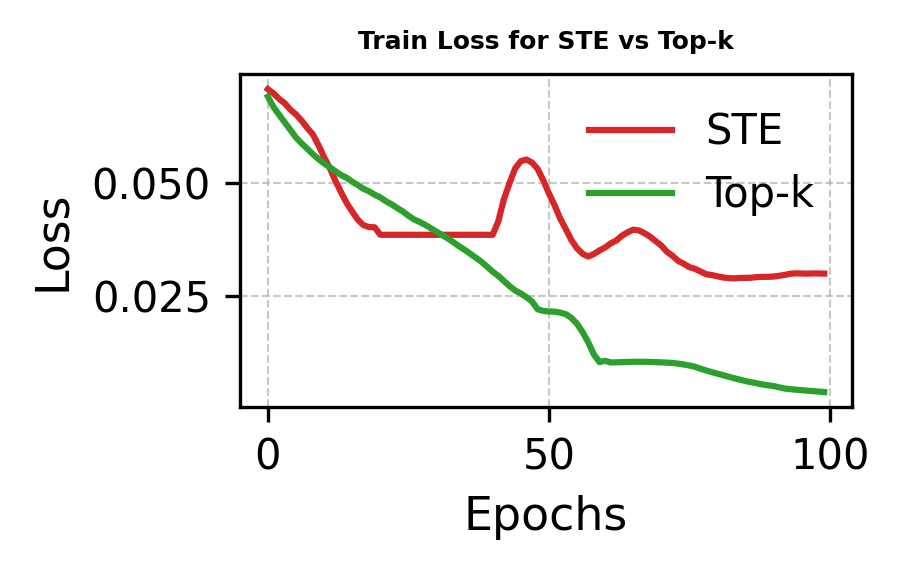

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 2), dpi=300)

colors = ['tab:red', 'tab:green']

for color, (name, (weight_evolution, loss_values)) in zip(colors, trajectories.items()):
    ax.plot(loss_values, label=name, color=color, linewidth=1.5)

# Set axis labels with specific font sizes and serif font
ax.set_xlabel('Epochs', fontsize=11, )
ax.set_ylabel('Loss', fontsize=11,)

# Title with font size 12 and serif font
ax.set_title('Train Loss for STE vs Top-k', fontsize=6, fontweight='bold')

# Grid with subtle styling
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Legend with font size 10 and no frame
ax.legend(frameon=False, fontsize=10)

fig.tight_layout()

# Save as PDF
fig.savefig("train_loss_class.pdf", format='pdf')

plt.show()


## Weight Evolution

In [22]:
teacher_model.linear1[0].weight.data

tensor([[ 1.0000,  1.0000],
        [-0.3358, -0.0228],
        [ 0.2496,  0.3591],
        [-0.3356, -0.6465],
        [-0.4129, -0.5402],
        [-0.5350,  0.3332],
        [ 0.2995,  0.4067],
        [-0.1155,  0.5677],
        [ 0.7027,  0.3628],
        [-0.3905, -0.2795],
        [-0.4548,  0.4580],
        [ 0.0788,  0.6746],
        [-0.0792,  0.6333],
        [ 0.3458, -0.0153],
        [-0.3641,  0.2833],
        [ 0.0392, -0.3575],
        [ 0.4114, -0.1082],
        [-0.6832, -0.3947],
        [ 0.6414,  0.2919],
        [-0.4768,  0.5518],
        [ 0.0230, -0.6564],
        [ 0.2088, -0.2220],
        [-0.2570,  0.0369],
        [-0.6439,  0.0175],
        [ 0.5729,  0.1398],
        [-0.0778,  0.3222],
        [-0.0619, -0.2279],
        [ 0.1713,  0.0750],
        [ 0.2681, -0.1856],
        [ 0.5731,  0.4746],
        [-0.2773,  0.2441]])

In [23]:
student_model_ste.linear1[0].weight.data

tensor([[-0.2499, -0.3205],
        [-0.3358, -0.0228],
        [ 0.2496,  0.3591],
        [-0.3356, -0.6465],
        [-0.4129, -0.5402],
        [-0.5350,  0.3332],
        [ 0.2995,  0.4067],
        [-0.1155,  0.5677],
        [ 0.7027,  0.3628],
        [-0.3905, -0.2795],
        [-0.4548,  0.4580],
        [ 0.0788,  0.6746],
        [-0.0792,  0.6333],
        [ 0.3458, -0.0153],
        [-0.3641,  0.2833],
        [ 0.0392, -0.3575],
        [ 0.4114, -0.1082],
        [-0.6832, -0.3947],
        [ 0.6414,  0.2919],
        [-0.4768,  0.5518],
        [ 0.0230, -0.6564],
        [ 0.2088, -0.2220],
        [-0.2570,  0.0369],
        [-0.6439,  0.0175],
        [ 0.5729,  0.1398],
        [-0.0778,  0.3222],
        [-0.0619, -0.2279],
        [ 0.1713,  0.0750],
        [ 0.2681, -0.1856],
        [ 0.5731,  0.4746],
        [-0.2773,  0.2441]])

/tmp/ipykernel_1855627/1462116713.py:15: UserWarning: linewidths is ignored by contourf
  contour = ax.contourf(w0, w1, z, levels=20, cmap='viridis', alpha=0.4, linewidths=5.0)


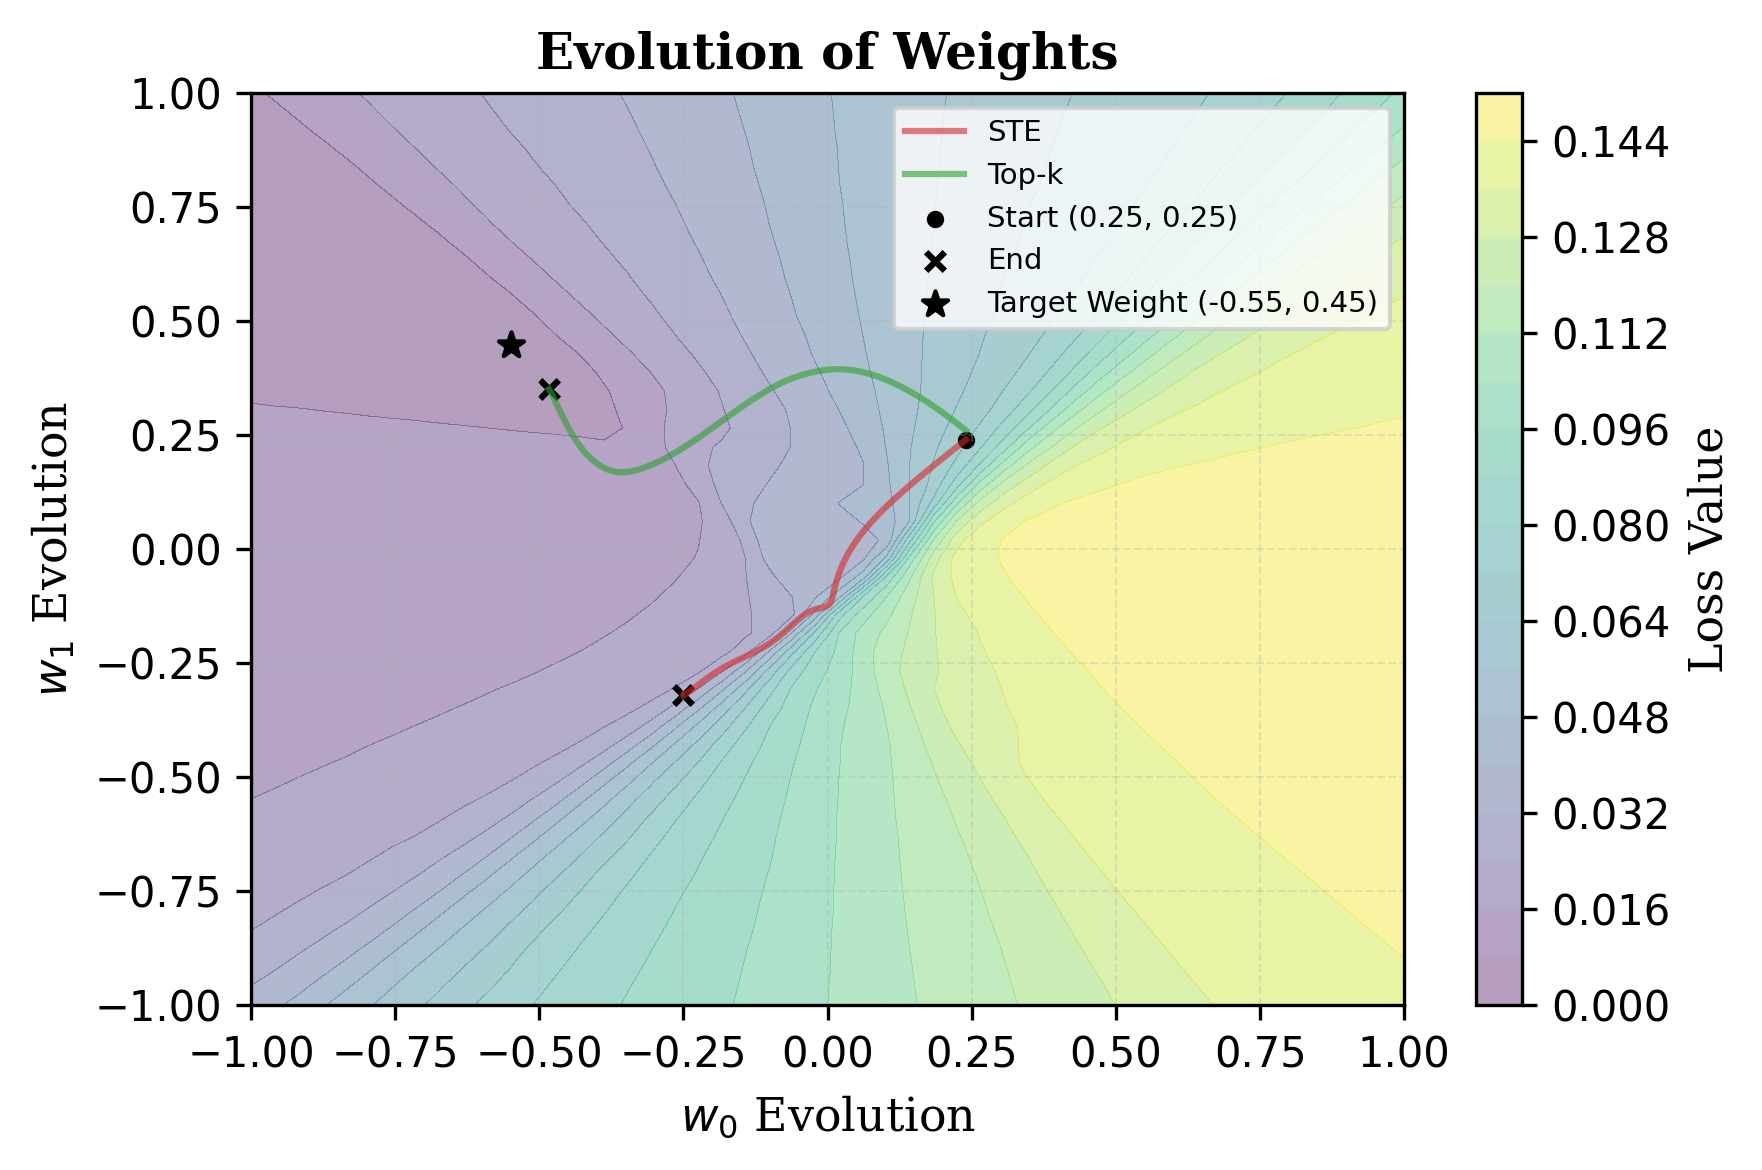

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Assuming 'trajectories' contains the weight evolution data for each STE method
# trajectories[name] = (weight_evolution, loss_values, weight_grad)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Define target weight
target_w = np.array([W1, W2])
w0, w1, z = loss_landscape

# Contour plot with colormap and alpha transparency
contour = ax.contourf(w0, w1, z, levels=20, cmap='viridis', alpha=0.4, linewidths=5.0)
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label("Loss Value", fontsize=11, fontfamily='serif')

# Colors for STE methods
colors = ['tab:red', 'tab:green', 'tab:blue', 'tab:purple']
scat_once = False

for i, (name, (weight_evolution, loss_values)) in enumerate(trajectories.items()):
    w_trajectory = weight_evolution[:, 0], weight_evolution[:, 1]  # separate components
    
    # Plot line trajectory with color and alpha
    ax.plot(w_trajectory[0], w_trajectory[1], linestyle='-', color=colors[i % len(colors)], alpha=0.6, label=name)
for i, (name, (weight_evolution, loss_values)) in enumerate(trajectories.items()):
    w_trajectory = weight_evolution[:, 0], weight_evolution[:, 1]  # separate components
    # Mark start and end points with scatter
    if not scat_once:
        ax.scatter(w_trajectory[0][0], w_trajectory[1][0], color='black', s=10, marker='o', label=f'Start ({initial_wt[0]:.2f}, {initial_wt[1]:.2f})')
        scat_once = True
    ax.scatter(w_trajectory[0][-1], w_trajectory[1][-1], color='black', s=20, marker='x', label='End' if i==0 else None)

# Plot target weight as black star
ax.scatter(target_w[0], target_w[1], color='black', s=40, marker='*', label=f"Target Weight ({W1:.2f}, {W2:.2f})")

# Axis labels with local font control
ax.set_xlabel(r'$w_0$ Evolution', fontsize=11, fontfamily='serif')
ax.set_ylabel(r'$w_1$ Evolution', fontsize=11, fontfamily='serif')

# Title with local font control
ax.set_title('Evolution of Weights',
             fontsize=12, fontfamily='serif', fontweight='bold')

# Legend with font family and size
ax.legend(frameon=True, fontsize=7)

# limit the axes to the range of w0 and w1
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

# Grid with subtle style
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)

fig.tight_layout()

# Save figure as PDF
fig.savefig("weight_evolution_class.pdf", format='pdf', bbox_inches='tight', dpi=300)

plt.show()


In [25]:
# 